# CPA attack on masked MAYO with 3 shares

<div class="alert" style="background-color: #ecfdf5; color: #064e3b; border: 1px solid #a7f3d0; font-size: 15px;">
<strong>Notebook overview:</strong> This notebook performs a CPA attack on the masked, three-share MAYO implementation. 
The attack targets the <code>P1P1t_times_O</code> function and uses pre-captured masked power traces together with precomputed call indices from <code>01_capture_mayo1_stm32f4.ipynb</code>. Some common helper functions for trace segmentation, leakage modeling, plotting, and result verification are implemented in <code>masked_attack_utils.py</code>.
<br><br>
<font color="#047857">→ Target:</font> masked MAYO with three shares</br>
<font color="#047857">→ Target function:</font> <code>P1P1t_times_O</code></br>
<font color="#047857">→ Input:</font> Raw masked power trace and precomputed peak indices</br>
<font color="#047857">→ Goal:</font> Recover the oil matrix using share-wise CPA</br>

In [5]:
from pathlib import Path
import sys
import numpy as np

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "data"

sys.path.insert(0, str(PROJECT_ROOT))

In [6]:
import numpy as np
import chipwhisperer as cw
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from masked_attack_utils import check_oil_vector, check_oil_matrix

### Choose data

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Select input trace:</strong> Set <code>input_trace</code> to the three-share masked trace that should be analyzed. 
An averaged trace with fixed shares is used to make the three share-specific regions easier to distinguish in the single-coefficient graphs.
</div>

In [7]:
from data.data import attack_O, attack_P2, attack_P1
masked_raw_trace = np.load(DATA_DIR/"3shares_masked_rawtrace.npy")
avg = np.load(DATA_DIR/"fixedsharesavg_5cap.npy")

In [3]:
input_trace = avg

### Precalculated segment size pattern from average trace

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Peak indices:</strong> The detected peak indices identify the call length for each segment in the captured trace. 
These indices were precomputed in the capture notebook and are used for trace segmentation below.
</div>

In [8]:
peaks = np.load(DATA_DIR/"3shares_peaks.npy")

## Trace Segmentation

In [5]:
from masked_attack_utils import (
    merge_oil_segments_for_share,
    build_segment_records, 
    get_oil_segment_records_for_share
)

## Precalculations

In [6]:
v = 78
o = 8
O = attack_O
limbs = 5

In [7]:
segment_records = build_segment_records(input_trace, peaks)

In [8]:
acc_state0 = np.array(attack_P2, dtype=np.uint64).reshape(v, o, limbs).copy()
acc_state1 = np.zeros((v, o, limbs), dtype=np.uint64)
acc_state2 = np.zeros_like(acc_state0)

In [9]:
from masked_attack_utils import (
    get_entries_for_coeff_share,
    get_P1_block
)

### Overlay of all oil segments for one coefficient

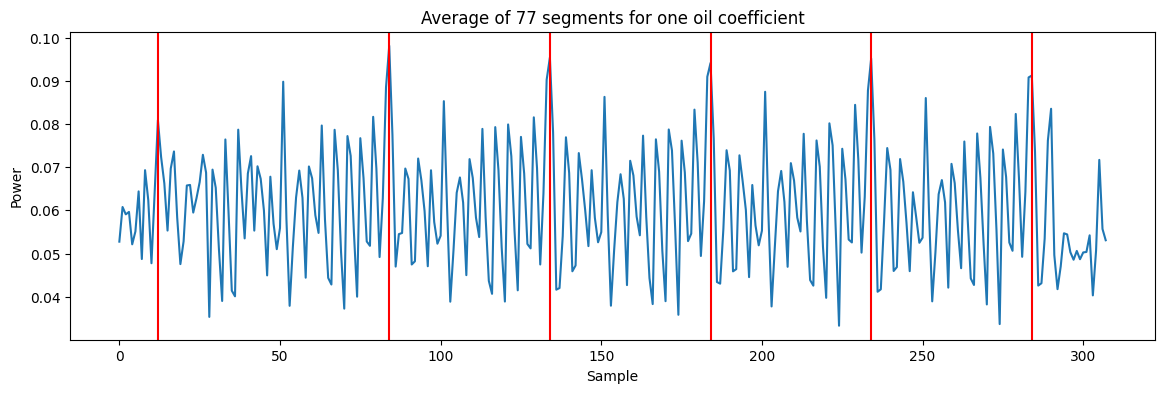

Peaks: [ 12  84 134 184 234 284]


In [10]:
from scipy.signal import find_peaks
oil_records_for_coeff = get_oil_segment_records_for_share(segment_records, z=0, k=0, share=1, v=78, o=8, n_shares=3)
merged_oil_segments = merge_oil_segments_for_share(oil_records_for_coeff, allowed_lengths=None, target_len=308)
seg = np.mean(np.asarray(merged_oil_segments, dtype=float), axis=0)

one =  merged_oil_segments[3]

peakstest, props = find_peaks(
    seg,
    height=0.02,
    distance=49
)

plt.figure(figsize=(14, 4))
plt.plot(seg)

for p in peakstest:
    plt.axvline(p, color='red')
plt.title("Average of 77 segments for one oil coefficient")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.show()

print("Peaks:", peakstest)

In [11]:
first_distances = np.diff(peakstest[:6])
print(first_distances)

[72 50 50 50 50]


## Correlation Power Analysis

### Leakage Modeling

In [12]:
from masked_attack_utils import (
    hw, 
    mul_table, 
    m_vec_mul_add_model,
    build_hypothesis_hw
)

### Correlation

In [13]:
from masked_attack_utils import (
    normalize_limbs,
    run_cpa,
)

## CPA on one oil coefficient

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Single-coefficient CPA:</strong> This section recovers one oil coefficient by attacking each share separately and XORing the recovered share guesses.
</div>

In [14]:
from masked_attack_utils import (
    plot_abs_share_correlations_n,
    recover_oil_share,
    recover_oil_from_n_shares
)

share guesses: [5, 11, 6]
oil guess: 8
share0 guess: 5
share0 best corr: 0.4564638271308051
share1 guess: 11
share1 best corr: 0.5486845041260285
share2 guess: 6
share2 best corr: 0.47759417141657057


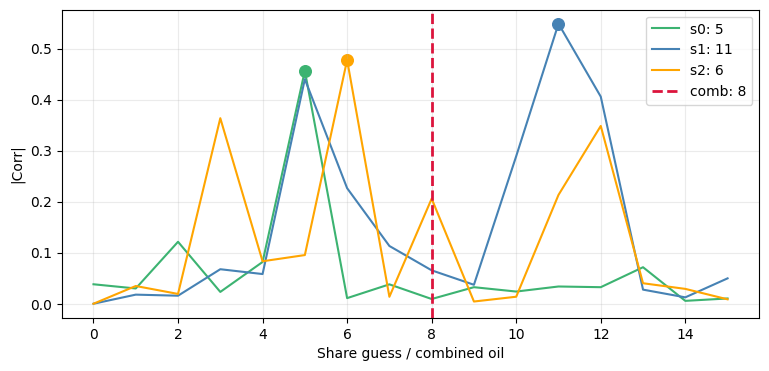

true oil:  8


In [15]:
v = 78
o = 8
limbs = 5

acc_state0 = np.array(attack_P2, dtype=np.uint64).reshape(v, o, limbs).copy()
acc_state1 = np.zeros_like(acc_state0)
acc_state2 = np.zeros_like(acc_state0)
acc_states3 = [acc_state0, acc_state1, acc_state2]

poi_list3 = [83, 133, 183, 233, 283]
poi_lists3 = [poi_list3, poi_list3, poi_list3]

k=0

guess_oil, guesses, corrs, debug = recover_oil_from_n_shares(
    segment_records=segment_records,
    acc_states=acc_states3,
    attack_P1=attack_P1,
    v=v,
    o=o,
    limbs=limbs,
    z=0,
    k=k,
    poi_lists=poi_lists3,
    target_len=308,
    n_shares=3,
    allowed_lengths=None,
)

print("share guesses:", guesses)
print("oil guess:", guess_oil)

for s, corr in enumerate(corrs):
    print(f"share{s} guess:", guesses[s])
    print(f"share{s} best corr:", np.max(np.abs(corr)))

plot_abs_share_correlations_n(
    corrs=corrs,
    guesses=guesses
)
O_mat = np.asarray(attack_O, dtype=np.uint8).reshape(v, o) & 0x0F
print("true oil: ", O_mat[0, k])

# CPA on one oil vector

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Oil-vector recovery:</strong> This section recovers one full oil-column vector. 
The attack follows the same row-by-row procedure as the unmasked attack, but applies it separately to each of the three shares. 
The recovered share vectors are then combined with XOR to obtain the final oil vector. 
The parameters <code>ambiguity_margin</code> and <code>lookahead_top_k</code> control when lookahead is used to resolve uncertain guesses.
</div>

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Result verification:</strong> The recovered vector or matrix is compared against the known reference oil matrix. 
A green result indicates a full match, while a red result indicates that at least one coefficient was recovered incorrectly.
</div>

In [16]:
from masked_attack_utils import update_acc_for_coeff

In [17]:
def recover_oil_vector_share(
    column,
    share,
    segment_records,
    acc_state_share,
    attack_P1,
    v,
    o,
    limbs,
    poi_list,
    num_rows=None,
    ambiguity_margin=0.2,
    lookahead_top_k=2,
    target_len=308,
    n_shares=3,
    allowed_lengths=None,
    zero_first_row_rule=True,
    zero_corr_threshold=0.1,
    zero_rule_shares=None,
):
    if num_rows is None:
        num_rows = v

    if zero_rule_shares is None:
        zero_rule_shares = list(range(1, n_shares))

    recovered_vector = []
    margins = []
    debug_rows = []

    def analyze_row(acc_state_local, row_idx):
        guess, corr, poi_lists_out, power, hyp, debug = recover_oil_share(
            segment_records=segment_records,
            acc_state_share=acc_state_local,
            attack_P1=attack_P1,
            v=v,
            o=o,
            limbs=limbs,
            z=row_idx,
            k=column,
            share=share,
            poi_list=poi_list,
            target_len=target_len,
            n_shares=n_shares,
            allowed_lengths=allowed_lengths,
        )

        abs_corr = np.abs(corr)
        guess = int(guess)
        winner_corr = corr[guess]

        masked = np.array(abs_corr, copy=True)
        masked[guess] = -np.inf

        next_best_guess = int(np.argmax(masked))
        next_best_corr = corr[next_best_guess]
        margin = abs_corr[guess] - abs_corr[next_best_guess]

        return {
            "guess": guess,
            "corr": corr,
            "winner_corr": winner_corr,
            "next_best_guess": next_best_guess,
            "next_best_corr": next_best_corr,
            "margin": margin,
            "debug": debug,
            "poi_lists": poi_lists_out,
            "power": power,
            "hyp": hyp,
        }

    for row in range(num_rows):
        analysis = analyze_row(acc_state_share, row)

        local_best = analysis["guess"]
        corr = analysis["corr"]
        local_winner_corr = analysis["winner_corr"]
        local_next_best_guess = analysis["next_best_guess"]
        local_next_best_corr = analysis["next_best_corr"]
        local_margin = analysis["margin"]

        final_guess = local_best
        final_margin = local_margin

        used_lookahead = False
        used_zero_rule = False
        lookahead_details = None

        max_abs_corr = float(np.max(np.abs(corr)))

        if (
            zero_first_row_rule
            and row == 0
            and share in zero_rule_shares
            and max_abs_corr < zero_corr_threshold
        ):
            final_guess = 0
            final_margin = local_margin
            used_zero_rule = True

        if (
            not used_zero_rule
            and row + 1 < num_rows
            and local_margin < ambiguity_margin
        ):
            used_lookahead = True

            abs_corr = np.abs(corr)
            top_candidates = np.argsort(abs_corr)[-lookahead_top_k:][::-1]

            best_candidate = None
            best_total_score = -np.inf
            best_info = None
            candidate_infos = []

            for cand in top_candidates:
                cand = int(cand)

                current_abs = np.abs(corr)
                current_corr = corr[cand]

                masked = np.array(current_abs, copy=True)
                masked[cand] = -np.inf

                current_next_best_guess = int(np.argmax(masked))
                current_next_best_corr = corr[current_next_best_guess]
                current_margin = (
                    current_abs[cand]
                    - current_abs[current_next_best_guess]
                )

                candidate_acc_state = update_acc_for_coeff(
                    acc_state=acc_state_share.copy(),
                    guessed_coeff=cand,
                    attack_P1=attack_P1,
                    v=v,
                    limbs=limbs,
                    z=row,
                    k0=column,
                )

                next_analysis = analyze_row(candidate_acc_state, row + 1)

                next_guess = next_analysis["guess"]
                next_winner_corr = next_analysis["winner_corr"]
                next_margin = next_analysis["margin"]

                total_score = (
                    np.abs(current_corr)
                    + current_margin
                    + np.abs(next_winner_corr)
                    + next_margin
                )

                info = {
                    "candidate": cand,
                    "current_corr": current_corr,
                    "current_margin": current_margin,
                    "next_guess": next_guess,
                    "next_winner_corr": next_winner_corr,
                    "next_margin": next_margin,
                    "total_score": total_score,
                }

                candidate_infos.append(info)

                if total_score > best_total_score:
                    best_total_score = total_score
                    best_candidate = cand
                    best_info = info

            final_guess = int(best_candidate)

            abs_corr = np.abs(corr)
            masked = np.array(abs_corr, copy=True)
            masked[final_guess] = -np.inf

            final_next_best_guess = int(np.argmax(masked))
            final_margin = abs_corr[final_guess] - abs_corr[final_next_best_guess]

            lookahead_details = {
                "candidates": candidate_infos,
                "chosen": best_info,
            }

        recovered_vector.append(final_guess)
        margins.append(final_margin)

        decision = (
            "ZERO_RULE"
            if used_zero_rule
            else ("LOOKAHEAD" if used_lookahead else "DIRECT")
        )

        print(
            f"share={share}, row={row:2d}, "
            f"local_best={local_best}, final_guess={final_guess}, "
            f"local_corr={local_winner_corr:.6f}, "
            f"max_abs_corr={max_abs_corr:.6f}, "
            f"next_best_guess={local_next_best_guess}, "
            f"next_best_corr={local_next_best_corr:.6f}, "
            f"local_margin={local_margin:.6f}, "
            f"{decision}"
        )

        if used_lookahead and lookahead_details is not None:
            print("    lookahead candidates:")
            for info in lookahead_details["candidates"]:
                print(
                    f"      cand={info['candidate']}, "
                    f"curr_corr={info['current_corr']:.6f}, "
                    f"curr_margin={info['current_margin']:.6f}, "
                    f"next_guess={info['next_guess']}, "
                    f"next_winner_corr={info['next_winner_corr']:.6f}, "
                    f"next_margin={info['next_margin']:.6f}, "
                    f"total_score={info['total_score']:.6f}"
                )

            chosen = lookahead_details["chosen"]
            print(
                f"    chosen_by_lookahead: cand={chosen['candidate']}, "
                f"next_guess={chosen['next_guess']}, "
                f"total_score={chosen['total_score']:.6f}"
            )

        if used_zero_rule:
            print(
                f"    zero_rule: row=0, share={share}, "
                f"max_abs_corr={max_abs_corr:.6f} < {zero_corr_threshold}, "
                f"forcing final_guess=0"
            )

        acc_state_share = update_acc_for_coeff(
            acc_state=acc_state_share,
            guessed_coeff=final_guess,
            attack_P1=attack_P1,
            v=v,
            limbs=limbs,
            z=row,
            k0=column,
        )

        debug_rows.append({
            "share": share,
            "row": row,
            "local_best": local_best,
            "final_guess": final_guess,
            "local_margin": local_margin,
            "final_margin": final_margin,
            "used_lookahead": used_lookahead,
            "used_zero_rule": used_zero_rule,
            "max_abs_corr": max_abs_corr,
            "zero_corr_threshold": zero_corr_threshold,
            "lookahead_details": lookahead_details,
            "analysis": analysis,
        })

    print(f"share={share} mean margin:", np.mean(margins))
    print(f"share={share} min margin :", np.min(margins))
    print(f"share={share} max margin :", np.max(margins))
    print(
        f"acc_state_share[{share}][0,0]:",
        [hex(int(x)) for x in acc_state_share[0, 0]],
    )

    return recovered_vector, acc_state_share, debug_rows

In [18]:
def recover_oil_vector_n_shares(
    column,
    segment_records,
    acc_list,
    attack_P1,
    v,
    o,
    limbs,
    poi_lists,
    n_shares,
    num_rows=None,
    ambiguity_margin=0.2,
    lookahead_top_k=2,
    target_len=308,
    allowed_lengths=None,
    zero_first_row_rule=True,
    zero_corr_threshold=0.12,
    zero_rule_shares=None,
):
    if num_rows is None:
        num_rows = v

    if len(acc_list) != n_shares:
        raise ValueError(f"acc_list must contain {n_shares} states")

    if len(poi_lists) != n_shares:
        raise ValueError(f"poi_lists must contain {n_shares} POI lists")

    if zero_rule_shares is None:
        zero_rule_shares = list(range(1, n_shares))

    share_vectors = []
    acc_states_after = []
    debug_by_share = []

    for share in range(n_shares):
        share_vec, acc_after, debug_rows = recover_oil_vector_share(
            column=column,
            share=share,
            segment_records=segment_records,
            acc_state_share=acc_list[share].copy(),
            attack_P1=attack_P1,
            v=v,
            o=o,
            limbs=limbs,
            poi_list=poi_lists[share],
            num_rows=num_rows,
            ambiguity_margin=ambiguity_margin,
            lookahead_top_k=lookahead_top_k,
            target_len=target_len,
            n_shares=n_shares,
            allowed_lengths=allowed_lengths,
            zero_first_row_rule=zero_first_row_rule,
            zero_corr_threshold=zero_corr_threshold,
            zero_rule_shares=zero_rule_shares,
        )

        share_vectors.append(share_vec)
        acc_states_after.append(acc_after)
        debug_by_share.append(debug_rows)

    oil_vector = []

    for row in range(num_rows):
        x = 0
        for share in range(n_shares):
            x ^= int(share_vectors[share][row])
        oil_vector.append(x)

    return oil_vector, share_vectors, acc_states_after, debug_by_share

In [19]:
acc_state0 = np.array(attack_P2, dtype=np.uint64).reshape(v, o, limbs).copy()
acc_state1 = np.zeros((v, o, limbs), dtype=np.uint64)
acc_state2 = np.zeros((v, o, limbs), dtype=np.uint64)

acc_list = [
    acc_state0.copy(),
    acc_state1.copy(),
    acc_state2.copy(),
]
column = 2

poi_list3_share0 = [82, 132, 182, 232, 282]
poi_list3_share1 = [83, 133, 183, 233, 283]
poi_list3_share2 = [71, 121, 171, 221, 271] 
poi_lists3 = [poi_list3_share1, poi_list3_share1, poi_list3_share1]
oil_vector, share_vectors, acc_states_after, debug_by_share = (
    recover_oil_vector_n_shares(
        column=column,
        segment_records=segment_records,
        acc_list=acc_list,
        attack_P1=attack_P1,
        v=v,
        o=o,
        limbs=limbs,
        poi_lists=poi_lists3,
        n_shares=3,
        ambiguity_margin=0.25,
        lookahead_top_k=3,
        target_len=308,
        allowed_lengths=None,
    )
)

share0_vec = share_vectors[0]
share1_vec = share_vectors[1]
share2_vec = share_vectors[2]

share=0, row= 0, local_best=13, final_guess=13, local_corr=0.389966, max_abs_corr=0.389966, next_best_guess=6, next_best_corr=-0.111546, local_margin=0.278420, DIRECT
share=0, row= 1, local_best=15, final_guess=15, local_corr=0.386704, max_abs_corr=0.386704, next_best_guess=11, next_best_corr=0.103431, local_margin=0.283274, DIRECT
share=0, row= 2, local_best=15, final_guess=15, local_corr=0.486739, max_abs_corr=0.486739, next_best_guess=3, next_best_corr=0.083179, local_margin=0.403560, DIRECT
share=0, row= 3, local_best=0, final_guess=0, local_corr=0.491205, max_abs_corr=0.491205, next_best_guess=14, next_best_corr=0.060494, local_margin=0.430711, DIRECT
share=0, row= 4, local_best=2, final_guess=2, local_corr=0.518468, max_abs_corr=0.518468, next_best_guess=7, next_best_corr=-0.141910, local_margin=0.376559, DIRECT
share=0, row= 5, local_best=9, final_guess=9, local_corr=0.509143, max_abs_corr=0.509143, next_best_guess=6, next_best_corr=-0.093734, local_margin=0.415409, DIRECT
share

In [20]:
check_oil_vector(oil_vector, attack_O, column, o=o)

Recovered oil vector:
[ 4  5 12  6 15  9  1  9  7 13  5  5  9  2  3  2 12 12  1  3  9 15  9 13
  2 12  5 14 15  9  6  8 14  0 13  4 10  8 12  4 11 15  3  5  8  2  5 11
 11  6 15  4  1  1  4  4 11 10  5 14 13  5  6  5  7  0 12  6  6  6 10  9
 11  2  7 11  3  5]
True oil vector:
[ 4  5 12  6 15  9  1  9  7 13  5  5  9  2  3  2 12 12  1  3  9 15  9 13
  2 12  5 14 15  9  6  8 14  0 13  4 10  8 12  4 11 15  3  5  8  2  5 11
 11  6 15  4  1  1  4  4 11 10  5 14 13  5  6  5  7  0 12  6  6  6 10  9
 11  2  7 11  3  5]


## CPA on full oil matrix

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Full matrix recovery:</strong> The full oil matrix is recovered column by column. 
Each coefficient is recovered by combining the three independently attacked shares.
</div>

In [21]:
def recover_oil_matrix_n_shares(
    segment_records,
    acc_list_init,
    attack_P1,
    v,
    o,
    limbs,
    poi_lists,
    n_shares,
    num_rows=None,
    ambiguity_margin=0.2,
    lookahead_top_k=2,
    target_len=308,
    allowed_lengths=None,
    zero_first_row_rule=True,
    zero_corr_threshold=0.12,
    zero_rule_shares=None,
):
    if num_rows is None:
        num_rows = v

    if zero_rule_shares is None:
        zero_rule_shares = list(range(1, n_shares))

    acc_list = [
        np.array(acc_list_init[s], copy=True)
        for s in range(n_shares)
    ]

    recovered_O_matrix = np.zeros((num_rows, o), dtype=np.int64)

    recovered_share_matrices = [
        np.zeros((num_rows, o), dtype=np.int64)
        for _ in range(n_shares)
    ]

    debug_by_column = []

    for column in range(o):
        print(f"\n===== Recovering column {column} =====")

        (
            oil_vector,
            share_vectors,
            acc_states_after,
            debug_by_share,
        ) = recover_oil_vector_n_shares(
            column=column,
            segment_records=segment_records,
            acc_list=acc_list,
            attack_P1=attack_P1,
            v=v,
            o=o,
            limbs=limbs,
            poi_lists=poi_lists,
            n_shares=n_shares,
            num_rows=num_rows,
            ambiguity_margin=ambiguity_margin,
            lookahead_top_k=lookahead_top_k,
            target_len=target_len,
            allowed_lengths=allowed_lengths,
            zero_first_row_rule=zero_first_row_rule,
            zero_corr_threshold=zero_corr_threshold,
            zero_rule_shares=zero_rule_shares,
        )

        recovered_O_matrix[:, column] = np.asarray(oil_vector, dtype=np.int64)

        for share in range(n_shares):
            recovered_share_matrices[share][:, column] = np.asarray(
                share_vectors[share],
                dtype=np.int64,
            )

        acc_list = [
            np.array(acc_states_after[s], copy=True)
            for s in range(n_shares)
        ]

        debug_by_column.append({
            "column": column,
            "oil_vector": oil_vector,
            "share_vectors": share_vectors,
            "debug_by_share": debug_by_share,
        })

    return (
        recovered_O_matrix,
        recovered_share_matrices,
        acc_list,
        debug_by_column,
    )

In [22]:
v = 78
o = 8
limbs = 5
n_shares = 3

acc_state0 = np.array(attack_P2, dtype=np.uint64).reshape(v, o, limbs).copy()
acc_state1 = np.zeros_like(acc_state0)
acc_state2 = np.zeros_like(acc_state0)

acc_list_init = [
    acc_state0.copy(),
    acc_state1.copy(),
    acc_state2.copy(),
]

poi_list3 = [83, 133, 183, 233, 283]

poi_lists3 = [
    poi_list3,
    poi_list3,
    poi_list3,
]

(
    recovered_O_matrix,
    recovered_share_matrices,
    acc_list_after,
    debug_by_column,
) = recover_oil_matrix_n_shares(
    segment_records=segment_records,
    acc_list_init=acc_list_init,
    attack_P1=attack_P1,
    v=v,
    o=o,
    limbs=limbs,
    poi_lists=poi_lists3,
    n_shares=3,
    ambiguity_margin=0.2,
    lookahead_top_k=3,
    target_len=308,
    allowed_lengths=None,
    zero_first_row_rule=True,
    zero_corr_threshold=0.12,
    zero_rule_shares=[1, 2],
)


===== Recovering column 0 =====
share=0, row= 0, local_best=5, final_guess=5, local_corr=0.456464, max_abs_corr=0.456464, next_best_guess=2, next_best_corr=-0.121367, local_margin=0.335097, DIRECT
share=0, row= 1, local_best=14, final_guess=14, local_corr=0.513395, max_abs_corr=0.513395, next_best_guess=13, next_best_corr=0.082168, local_margin=0.431227, DIRECT
share=0, row= 2, local_best=6, final_guess=6, local_corr=0.455085, max_abs_corr=0.455085, next_best_guess=0, next_best_corr=-0.108112, local_margin=0.346973, DIRECT
share=0, row= 3, local_best=0, final_guess=0, local_corr=0.477909, max_abs_corr=0.477909, next_best_guess=11, next_best_corr=-0.097167, local_margin=0.380742, DIRECT
share=0, row= 4, local_best=4, final_guess=4, local_corr=0.384411, max_abs_corr=0.384411, next_best_guess=2, next_best_corr=-0.123626, local_margin=0.260785, DIRECT
share=0, row= 5, local_best=12, final_guess=12, local_corr=0.465315, max_abs_corr=0.465315, next_best_guess=15, next_best_corr=0.094205, lo

In [23]:
check_oil_matrix(recovered_O_matrix, attack_O, v, o)